# Global river flood hazard from JRC's public LISFLOOD maps

**crc-sdk** resolves, caches, and canonicalizes JRC's public flood maps through one lazy `HazardDataset` workflow.

1. **Hazard** — select a Toronto AOI from the [JRC](https://joint-research-centre.ec.europa.eu) Global River Flood Hazard Map, cache AOI crops for every published return period, and materialize canonical H3 curves.
2. **Escalation** — compare exposed-cell count and depth across return periods, from a 1-in-10-year to a 1-in-500-year event.
3. **Visualize** — a depth map at the 100-year return period, and a return-period comparison.

Nothing is bundled with this notebook. The first terminal run downloads only the AOI windows under `data/jrc-source-cache`; later runs reuse the pinned source release and canonical Parquet.

In [1]:
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from shapely.geometry import mapping

from crc_sdk.connectors import read_hazard_dataset
from crc_sdk.geometry import cell_polygon
from crc_sdk.workflows import (
    HazardDataset,
    JRCFloodPolicy,
    curve_quantiles_at,
    return_periods_to_probabilities,
    warn_if_extrapolated,
)

# GitHub's notebook preview only renders static HTML/images (no JS execution),
# so every fig.show() below emits both an interactive widget (for local/Jupyter
# use) and a static PNG fallback (via kaleido) that GitHub's viewer displays.
pio.renderers.default = "jupyterlab+png"

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

RETURN_PERIODS = [10, 50, 100, 500]
BOUNDS = (-79.65, 43.58, -79.15, 43.85)  # downtown Toronto + Don/Humber river corridors
DESIGN_RETURN_PERIOD = 100

## 1. Hazard: JRC global river flood depth → one fitted curve per H3 cell

The [Joint Research Centre](https://joint-research-centre.ec.europa.eu)'s **Global River Flood Hazard Maps** (CEMS-GLOFAS v2.1.2, [CC BY 4.0](https://data.jrc.ec.europa.eu)) are built on the same LISFLOOD hydrology/hydrodynamics model family used internally for city-scale flood extraction — just released as public, global ~90m return-period rasters instead of a private downscaled dataset.

`HazardDataset.glofas(...).for_area(...)` resolves the tiles internally. Builder calls are immutable and perform no network work; `materialize()` pins `latest`, caches AOI crops for all seven published source periods, and fits one canonical curve per source pixel. The four periods below are evaluation periods, separate from the complete source-period fit. All fall within its RP10-RP500 support, so they are interpolated (or evaluated at endpoints), not extrapolated; a request such as RP1000 emits an explicit warning.

In [2]:
CURVES_PATH = DATA_DIR / "jrc_toronto_curves.parquet"

plan = (
    HazardDataset.glofas(version="latest")
    .for_area(BOUNDS)
    .cache(DATA_DIR / "jrc-source-cache", mode="reuse")
    .source_periods("all")
    .canonicalize(policy=JRCFloodPolicy.curated(h3_resolution=9))
)
print(plan.explain())
hazard_dataset = (
    HazardDataset.local(CURVES_PATH)
    if CURVES_PATH.exists()
    else plan.materialize(CURVES_PATH)
)
if hazard_dataset.metadata().return_period_support is None:
    hazard_dataset = plan.materialize(CURVES_PATH)

# Round-trip through the canonical contract: read back the file just
# written, then reconstruct a depth at each requested return period --
# the same read path `pipelines/jrc_flood_pipeline.py` and the
# asset-portfolio track both use.
metadata = hazard_dataset.metadata()
warn_if_extrapolated(RETURN_PERIODS, metadata.return_period_support)
curves = read_hazard_dataset(hazard_dataset.provider.source)
depths = pd.concat(
    [
        pd.DataFrame(
            {
                "cell": curves["cell_index"].to_pylist(),
                "depth_m": curve_quantiles_at(curves, probability),
                "return_period": rp,
            }
        )
        for rp, probability in zip(
            RETURN_PERIODS,
            return_periods_to_probabilities(
                RETURN_PERIODS, tail=metadata.return_period_tail
            ),
        )
    ],
    ignore_index=True,
)
# Conservative H3 overlap can map multiple source pixels to one cell.
depths = depths.groupby(["cell", "return_period"], as_index=False).max()
print(
    f"{len(depths):,} cell-return-period rows across "
    f"{depths['cell'].nunique():,} distinct H3 cells"
)

11,416 cell-return-period rows across 2,854 distinct H3 cells


## 2. Escalation: exposed cells and depth by return period

The same H3 cells recur across return periods (a rarer event floods a superset of what a common one does), so grouping by `return_period` alone — no join needed — already shows how both the flooded footprint and its depth grow from a 1-in-10-year to a 1-in-500-year event.

In [3]:
summary = (
    depths.groupby("return_period")
    .agg(
        exposed_cells=("cell", "nunique"),
        mean_depth_m=("depth_m", "mean"),
        max_depth_m=("depth_m", "max"),
    )
    .reset_index()
)
summary

,return_period,exposed_cells,mean_depth_m,max_depth_m
0,10,2854,0.999318,12.967588
1,50,2854,1.293104,13.156993
2,100,2854,1.417349,13.237196
3,500,2854,1.705474,13.422531


## 3. Visualize

A depth map at the design return period (100 years), and an escalation chart across all four sampled return periods. Depth uses one sequential warm scale (YlOrRd) throughout — a magnitude, never a diverging quantity — and a dark basemap keeps the many low-depth cells legible instead of washing out against a light one.

JRC's own documentation flags that depths above ~10m near small channels can be modeling artifacts (DEM sinks or tile-boundary effects) rather than real hazard — worth keeping in mind for any outlier cell, and a direct parallel to the tile-edge duplicate/artifact handling the internal pipeline already does for its own higher-resolution rasters.

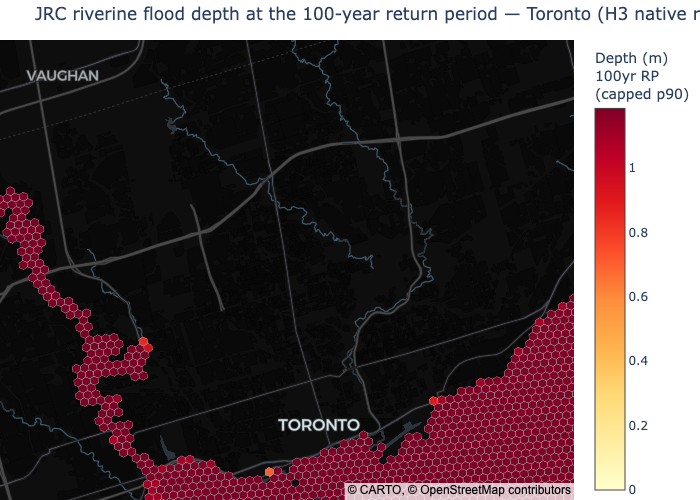

In [4]:
MAP_STYLE = "carto-darkmatter"  # dark basemap: low depths stay legible, unlike on a light one
depths_design_rp = depths[depths["return_period"] == DESIGN_RETURN_PERIOD]

hex_geojson = {
    "type": "FeatureCollection",
    "features": [
        {"type": "Feature", "id": str(cell), "geometry": mapping(cell_polygon(cell))}
        for cell in depths_design_rp["cell"]
    ],
}

# A handful of extreme (possibly artifact) cells would otherwise stretch the
# scale so far that the other 90% of (still meaningful) depths all read as
# the same pale color.
depth_cap = depths_design_rp["depth_m"].quantile(0.90)

fig_hex = go.Figure(
    go.Choroplethmap(
        geojson=hex_geojson,
        locations=depths_design_rp["cell"].astype(str),
        z=depths_design_rp["depth_m"],
        zmin=0,
        zmax=depth_cap,
        colorscale="YlOrRd",
        marker_line_width=0.3,
        marker_line_color="#999999",
        marker_opacity=0.95,
        colorbar_title=f"Depth (m)<br>{DESIGN_RETURN_PERIOD}yr RP<br>(capped p90)",
    )
)
fig_hex.update_layout(
    map_style=MAP_STYLE,
    map_zoom=10.3,
    map_center={"lat": (BOUNDS[1] + BOUNDS[3]) / 2, "lon": (BOUNDS[0] + BOUNDS[2]) / 2},
    margin=dict(l=0, r=0, t=40, b=0),
    title=(
        f"JRC riverine flood depth at the {DESIGN_RETURN_PERIOD}-year return period "
        "— Toronto (H3 native resolution)"
    ),
)
fig_hex.show()

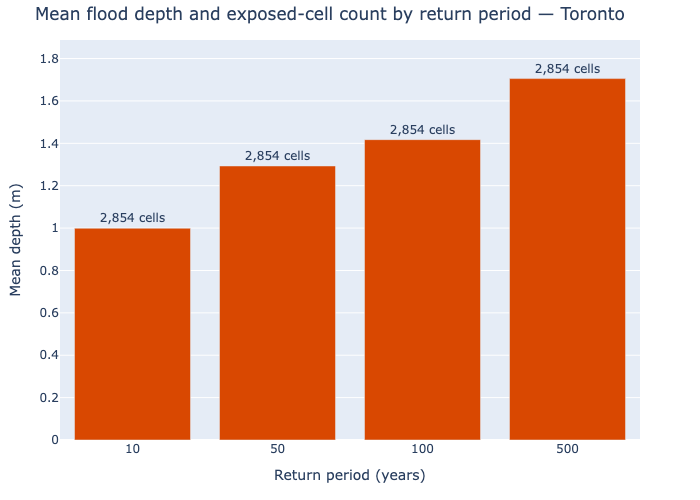

In [5]:
ranked = summary.sort_values("return_period")
fig_escalation = go.Figure(
    go.Bar(
        x=[str(rp) for rp in ranked["return_period"]],
        y=ranked["mean_depth_m"],
        marker_color="#D94801",
        text=ranked["exposed_cells"],
        texttemplate="%{text:,} cells",
        textposition="outside",
        customdata=ranked[["max_depth_m"]],
        hovertemplate=(
            "RP %{x}yr<br>Mean depth: %{y:.2f} m"
            "<br>Max depth: %{customdata[0]:.2f} m<extra></extra>"
        ),
    )
)
fig_escalation.update_layout(
    title="Mean flood depth and exposed-cell count by return period — Toronto",
    xaxis_title="Return period (years)",
    yaxis_title="Mean depth (m)",
    margin=dict(l=60, r=60, t=40, b=60),
)
fig_escalation.show()

## Scaling this up

[`pipelines/jrc_flood_pipeline.py`](../pipelines/jrc_flood_pipeline.py) is this notebook's headless twin: the same area → AOI cache → canonical Parquet workflow with explicit reuse, refresh, and offline cache modes. Widen `--bounds` to scale the run; source discovery remains inside the plan and raster reads remain strip-bounded.